
# The AI model boom → a 3‑layer ranking‑race reel, by **downloads**
### Your fourth end‑to‑end project with **gradient‑sankey** — built *com todo cuidado e carinho* 🤖💙

Welcome back! 👋 This is the **fourth** lesson in the onboarding series, and the one closest to home:
we're going to animate **the AI model boom itself**, using the **Hugging Face Hub** — the place where
most of the world's open models actually live.

We'll reproduce, **end to end**, the **AI‑model‑boom ranking‑race reel**: real Hub data flowing across
**three** columns —

1. **organisations** (Meta, Google, Qwen, OpenAI, microsoft, nvidia, BAAI, deepseek‑ai, SBERT, …),
   ranked by their **total downloads** — the famous labs, surfaced by *reach*,
2. the **modality** each model serves (**Text / Image / Audio / Video / Multimodal / Other**),
3. and — the new headline — the **single #1 model** in each modality lane (Text → `all‑MiniLM‑L6‑v2`,
   Image → `clip‑vit‑base‑patch32`, …), with **one shared neutral *"Demais modelos"* node** that *all*
   lanes route their non‑flagship downloads into, so each lane **balances honestly** without six clutter
   nodes.

Animated **month by month** as the field explodes — Text dominant early, then Image, Audio, Multimodal
and Video lighting up as models go multimodal, and the famous flagship models surfacing the month they
were created.

> The three earlier tutorials taught the tidy `[time, source, target, value]` contract, the dynamic
> top‑N, the **"Others"** bucket, and **`dynamic_color_mode="ranking"`**. Here we reuse all of that and
> add **three** new skills: ranking by a **weighted metric (downloads, not counts)**, turning a **flat
> REST listing into a *cumulative* race**, and building a **balanced THREE‑layer Sankey**
> (org → modality → flagship model).

---

### What we'll build

A **ranking race** with **three** columns. On the **left**, model **organisations** ranked by their
**total downloads**; in the **middle**, the **modality** each model serves; on the **right**, the
**flagship model** of each lane (its all‑time #1 by downloads) next to **one shared neutral
*"Demais modelos"*** node. Ribbons flow org → modality → flagship, their width is **downloads**
(cumulative), and **every frame is one month** — *cumulative*, so values only ever grow and a lane
lights up the month a modality takes off. A neutral **"Others"** org soaks up the long tail, and a
footer chart tracks the **cumulative downloads** (in **billions**) in our sample **month by month**.

The star again: **`dynamic_color_mode="ranking"`** repaints every org by its *live* rank each frame, so
the organisation leading the boom that month is unmistakable.

### Learning outcomes

1. Call the **free Hugging Face Hub REST API** (no key) and read its raw model JSON.
2. **Bucket** a messy categorical field (`pipeline_tag`) into coarse **modality** lanes — and reason
   about the edge cases (`image-text-to-text` is *Multimodal*, `None` is *Other*, …).
3. Rank organisations by a **weighted metric (total downloads)** instead of a raw count, so the
   *recognisable* labs surface.
4. Turn a **flat listing** into a **cumulative**, **monthly** long‑form frame — sum downloads of models
   *created up to and including* each **year‑month**.
5. Build a **balanced THREE‑layer** Sankey: per modality, split the lane total into **[#1 model] + [the
   ONE shared "Demais modelos" node]** so `in == out` and the famous name is highlighted while a *single*
   neutral node absorbs every lane's long tail.
6. Drive `gradient_sankey` with **`dynamic_color_mode="ranking"`**, a **downloads** value axis
   (billions), `layer0_label_side`, and a **monthly** cumulative‑total **overlay** with `overlay_band`.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it imports
> only `gradient_sankey` (the committed module at the repo root), the Python standard library, and the pip
> packages `pandas` and `requests`. Every fetch and every helper — `fetch_models`, `bucket_modality`, the
> cumulative monthly flow builder — is **inlined below as a teaching step**, so you can read the whole ETL
> pipeline end to end. 💙

> ⚠️ **Honest scope, up front.** We work from a **top‑by‑downloads sample** of the Hub (the few‑thousand
> most‑downloaded models), **not** the full ~1.9M‑model Hub. The **modality** is *our* bucketing of
> `pipeline_tag`, not an official Hub taxonomy. And `createdAt` is a model's **upload** date, which for
> re‑uploaded landmark models is *not* its true birth year. Crucially, **HF `downloads` is a current
> ~30‑day snapshot** — so the **monthly overlay** below is the *cumulative download‑power accrued by
> models existing by each month*, **not** historically‑realised monthly download traffic. All of these
> are deliberate (fast, readable) — we flag them again where they bite.



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We add the
repo root to `sys.path` so we always get the **local** copy with the newest features.

```bash
pip install gradient-sankey        # the public package
# this notebook uses the LOCAL repo copy via sys.path (see below)
```

> ⚠️ **Heads‑up — local‑only features (shipping in the next release, v1.3.0).** This reel leans on a few
> capabilities that already exist in the **local** `gradient_sankey.py` but are **not yet on the
> published pip package**:
> - **`dynamic_color_mode="ranking"`** with a **`dynamic_colormap`** (e.g. `"plasma"`) — recolour every
>   node by its live rank each frame,
> - pinning a node named exactly **`"Others"`** to the **bottom** of the race **and** keeping it a fixed
>   neutral colour even under dynamic colouring,
> - **hiding zero‑value nodes** (so a flagship model can appear mid‑story the year it was created, and
>   an empty lane can vanish cleanly),
> - the **layer‑total value axis** (`yaxis_node`) with **`value_prefix=""`** + **`yaxis_suffix="B"`**
>   (downloads in billions, not dollars), plus **`yaxis_gap`** and **`layer0_label_side`**,
> - the **`overlay_band`** control (push the footer line chart lower, clear of the Sankey).
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We only need `requests` + `pandas` for the data, and the library for the visuals. Rendering an **MP4**
also needs **FFmpeg** on your PATH — but the still frames (`save_frame`) need nothing extra, so the
notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, json, pathlib, collections

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import requests
import pandas as pd
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the one Hugging Face Hub download, so a re-run is
# instant. Re-fetching from the Hub on a clean run is fine (free, no API key).
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("cache ->", CACHE)


gradient-sankey version: 1.2.2
pandas: 3.0.1
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2 · A 2‑minute Hugging Face Hub primer

The **[Hugging Face Hub](https://huggingface.co/)** hosts most of the world's open models and exposes a
**free, key‑less** REST API. We need exactly one endpoint:

```
GET https://huggingface.co/api/models?sort=downloads&direction=-1&limit=1000&skip=..&full=false
```

- **`sort=downloads&direction=-1`** = give me the **most‑downloaded** models first.
- **`limit`** + **`skip`** = page through them (the API caps `limit` at 1000, so we page).
- **`full=false`** = a trimmed payload — enough fields for us, much smaller.

Each model is a JSON object. The fields we care about:

| Field | Meaning |
|---|---|
| `id` | `org/name` — the **organisation** is the part before the `/`, the **model name** after it |
| `downloads` | all‑time download count — **the metric we rank, sample AND size flows by** |
| `likes` | community likes |
| `pipeline_tag` | the model's **task** (`text-generation`, `text-to-image`, `automatic-speech-recognition`, …) — our **modality** raw material |
| `createdAt` | ISO timestamp — the model's **upload month** (`YYYY-MM`, the first 7 chars; we cadence the reel monthly) |

> ### One honest caveat about coverage 🔬
> Sorting by downloads means our sample is **the popular Hub**, not the whole Hub. Older landmark models
> (BERT, GPT‑2) can also report a fairly recent `createdAt` (a re‑upload/migration date), so the early
> years skew toward "famous models that are still downloaded today" rather than a true census of *every*
> model created that year. We'll **say so** in the title and overlay label — honesty over hype.



## 3 · Scraping the data

We page through the **top‑`N_MODELS`** models by downloads, keeping only the light fields we need, and
**disk‑cache** the result under our local `.nbcache/` (`hf_models_top<N>.json`) — so a re‑run is instant,
and a fresh user fetches their own copy once. `fetch_models` loops `skip` in pages of 1000, collects the
trimmed records, and writes the JSON to disk.

> 🪶 To keep the lesson fast we sample **2000** models. Same logic at any size — a bigger sample just
> fills the lanes in a touch more.


In [2]:
HF = "https://huggingface.co/api/models"
UA = {"User-Agent": "gradient-sankey-ai-models-reel/1.0 (+github.com/FG-SC/gradient-sankey)"}

N_MODELS = 2000      # top-by-downloads sample size (bump for a bigger sample)

def fetch_models(n_models=N_MODELS, page=1000):
    """Top-`n_models` models by downloads, paged & disk-cached. A SAMPLE of the
    popular Hub, not the whole Hub. We keep only the light fields we need (id,
    downloads, likes, pipeline_tag, createdAt) so the cache stays small."""
    cf = CACHE / f"hf_models_top{n_models}.json"
    if cf.exists():
        return json.loads(cf.read_text(encoding="utf-8"))
    rows = []
    for skip in range(0, n_models, page):
        params = dict(sort="downloads", direction=-1, limit=min(page, n_models - skip),
                      skip=skip, full="false")
        r = requests.get(HF, params=params, headers=UA, timeout=90)
        r.raise_for_status()
        chunk = r.json()
        if not chunk:
            break
        for m in chunk:
            rows.append({
                "id": m.get("id", ""),
                "downloads": m.get("downloads", 0) or 0,
                "likes": m.get("likes", 0) or 0,
                "pipeline_tag": m.get("pipeline_tag"),
                "createdAt": m.get("createdAt", ""),
            })
    cf.write_text(json.dumps(rows), encoding="utf-8")
    return rows

models = fetch_models()
print(f"fetched {len(models)} models (top-by-downloads sample)")


fetched 2000 models (top-by-downloads sample)



Let's look at one **raw record** so the field shapes are concrete — the single most‑downloaded model in
our sample. Note its huge `downloads` count: that number is the star of this whole reel.


In [3]:
# the #1 most-downloaded model in the sample, so the API shape is concrete
top1 = models[0]
print(json.dumps(top1, indent=2))
print("\norg       =", top1["id"].split("/")[0] if "/" in top1["id"] else "(none)")
print("model     =", top1["id"].split("/", 1)[1] if "/" in top1["id"] else top1["id"])
print("year      =", (top1["createdAt"] or "")[:4])
print("task      =", top1["pipeline_tag"])
print("downloads =", f"{top1['downloads']:,}")


{
  "id": "sentence-transformers/all-MiniLM-L6-v2",
  "downloads": 170500268,
  "likes": 4956,
  "pipeline_tag": "sentence-similarity",
  "createdAt": "2022-03-02T23:29:05.000Z"
}

org       = sentence-transformers
model     = all-MiniLM-L6-v2
year      = 2022
task      = sentence-similarity
downloads = 170,500,268



## 4 · Bucketing `pipeline_tag` → modality

The Hub has **~50** task tags. To get a readable Sankey we fold them into **six** coarse lanes:
**Text, Image, Audio, Video, Multimodal, Other**. This is the trickiest *modelling* choice in the whole
project, so let's do it carefully — this is our `bucket_modality` function.

The **order of the checks matters**:

- **Video first** (`image-to-video` contains "image" but is really Video).
- **Cross‑modal tasks → Multimodal**: `image-text-to-text` (vision‑language models like Qwen‑VL),
  `any-to-any`, `visual-question-answering`, `document-question-answering`, `audio-text-to-text`.
- then **Audio** (speech/voice), then **Image** (vision tasks), then **Text** (the big catch‑all of
  language tasks), and finally **Other** for `None`, tabular, RL, graph, robotics, …

> ⚠️ **This bucketing is a judgement call, not gospel.** Reasonable people would slot
> `feature-extraction` or `sentence-similarity` differently (we call them *Text*). The point is a
> *readable* story, and we **state the rule** so it's reproducible and arguable.


In [4]:
MODALITIES = ["Text", "Image", "Audio", "Video", "Multimodal", "Other"]

def bucket_modality(pipeline_tag):
    """Fold a Hub `pipeline_tag` into a coarse modality lane. Order matters:
    video before image, the cross-modal 'to-text' tasks before plain image/text."""
    if not pipeline_tag:
        return "Other"
    t = pipeline_tag.lower()
    if "video" in t:
        return "Video"
    if ("image-text-to-text" in t or "any-to-any" in t or "visual-question" in t
            or "document-question" in t or "audio-text-to-text" in t or "multimodal" in t):
        return "Multimodal"
    if any(k in t for k in ("audio", "speech", "voice")):
        return "Audio"
    if ("image" in t or "visual" in t or "object-detection" in t or "depth" in t
            or "mask-generation" in t or "segmentation" in t):
        return "Image"
    if any(k in t for k in ("text", "token", "translation", "summar", "question",
                            "sentence", "fill-mask", "feature-extraction",
                            "classification", "ranking", "similar", "zero-shot",
                            "table-question", "fill-in")):
        return "Text"
    return "Other"

# sanity-check the rule against the actual tags present, biggest tags first
tag_counts = collections.Counter(m.get("pipeline_tag") for m in models)
print(f"{len([t for t in tag_counts if t])} distinct pipeline_tags in the sample. How they bucket:\n")
print(f"  {'pipeline_tag':32s} {'count':>6}  ->  modality")
for tag, n in tag_counts.most_common(18):
    print(f"  {str(tag):32s} {n:>6}  ->  {bucket_modality(tag)}")


46 distinct pipeline_tags in the sample. How they bucket:

  pipeline_tag                      count  ->  modality
  text-generation                     475  ->  Text
  image-text-to-text                  275  ->  Multimodal
  None                                262  ->  Other
  automatic-speech-recognition        132  ->  Audio
  sentence-similarity                 109  ->  Text
  feature-extraction                   95  ->  Text
  fill-mask                            72  ->  Text
  text-classification                  60  ->  Text
  token-classification                 59  ->  Text
  image-classification                 51  ->  Image
  text-to-image                        38  ->  Image
  zero-shot-image-classification       35  ->  Image
  any-to-any                           32  ->  Multimodal
  time-series-forecasting              30  ->  Other
  translation                          29  ->  Text
  image-feature-extraction             29  ->  Image
  text-to-speech                  


## 5 · Exploring the data — counts **vs** downloads

Here is the single most important modelling decision in this reel: **what do we measure?**

- **By model count**, the left column fills with bulk uploaders — orgs that publish *hundreds* of small
  fine‑tunes (`OpenMed`, `unsloth`, internal testing accounts). Technically true, but not the story
  anyone means by "the AI model boom".
- **By downloads** (total *reach*), the left column surfaces the **recognisable labs**: SBERT, Qwen,
  Google, Meta, BAAI, OpenAI, microsoft, deepseek‑ai, … — the orgs whose models the world actually
  *uses*. **That's** the story, so **downloads is our headline metric** for every layer.

Let's see the contrast directly, plus the per‑year modality mix.

> 🗓️ **A note on cadence.** This reel runs **monthly**, so we key each model by its createdAt
> **year‑month** (`"YYYY-MM"`), not just the year. In our top‑by‑downloads sample the createdAt dates
> only reach back to ~**2022‑03** (older landmark models report recent re‑upload dates), so we start the
> monthly window at **`START_MONTH = "2022-01"`** — no hundreds of near‑empty early months.


In [5]:
START_MONTH = "2022-01"   # monthly window start (createdAt dates barely predate 2022-03)

# build a flat (born-month, model_id, org, modality, downloads) table for exploration
def short_org(org):
    SHORT = {"facebook": "Meta", "FacebookAI": "Meta", "meta-llama": "Meta",
             "google-bert": "Google", "google-t5": "Google", "google": "Google",
             "sentence-transformers": "SBERT", "cross-encoder": "SBERT",
             "openai-community": "OpenAI", "openai": "OpenAI",
             "stabilityai": "Stability", "mistralai": "Mistral",
             "lmstudio-community": "LM Studio"}
    return SHORT.get(org, org)

recs = []
for m in models:
    ym = (m.get("createdAt") or "")[:7]               # "YYYY-MM"
    if len(ym) != 7 or not (ym[:4].isdigit() and ym[5:7].isdigit()):
        continue
    if ym < START_MONTH:                              # trim near-empty pre-window months
        continue
    mid = m["id"]
    org = short_org(mid.split("/")[0] if "/" in mid else "(none)")
    # downloads carried in BILLIONS so the axis/overlay read cleanly ("1B", "2B")
    recs.append((ym, mid, org, bucket_modality(m.get("pipeline_tag")),
                 (m.get("downloads", 0) or 0) / 1e9))
flat = pd.DataFrame(recs, columns=["born", "id", "org", "modality", "dl"])
print(f"{len(flat)} models with a valid month, {flat.born.min()}-{flat.born.max()}, "
      f"{flat.dl.sum():.1f}B downloads total\n")

print("Top orgs by MODEL COUNT (the bulk-uploader story — NOT what we want):")
display(flat["org"].value_counts().nlargest(8).rename("models"))

print("Top orgs by DOWNLOADS in billions (the recognisable labs — our headline metric):")
display(flat.groupby("org")["dl"].sum().nlargest(8).round(2).rename("downloads (B)"))

print("Downloads (B) by modality and year (born-year derived from the month):")
display(flat.assign(yr=flat.born.str[:4]).pivot_table(index="yr", columns="modality", values="dl",
                    aggfunc="sum", fill_value=0).round(2))


2000 models with a valid month, 2022-03-2026-06, 1.8B downloads total

Top orgs by MODEL COUNT (the bulk-uploader story — NOT what we want):


org
Qwen         166
Meta          96
Google        90
microsoft     64
unsloth       61
nvidia        60
LM Studio     48
timm          47
Name: models, dtype: int64

Top orgs by DOWNLOADS in billions (the recognisable labs — our headline metric):


org
SBERT          0.31
Qwen           0.22
Google         0.15
Meta           0.11
BAAI           0.10
OpenAI         0.07
microsoft      0.03
deepseek-ai    0.03
Name: downloads (B), dtype: float64

Downloads (B) by modality and year (born-year derived from the month):


modality,Audio,Image,Multimodal,Other,Text,Video
yr,,,,,,
2022,0.08,0.06,0.00,0.06,0.52,0.0
2023,0.04,0.04,0.00,0.04,0.12,0.0
2024,0.03,0.02,0.02,0.05,0.20,0.0
2025,0.01,0.02,0.05,0.05,0.15,0.0
2026,0.01,0.00,0.12,0.02,0.04,0.0



## 6 · Cleaning + the clever bits

Three ideas turn this flat listing into a balanced three‑layer race.

### 6.1 · Top‑N orgs **by downloads** — *drop the long tail* (no dominant "Others")

We only draw the **top‑`N_ORGS`** organisations **by total downloads** (not model count!). The download
long‑tail is huge — roughly a thousand orgs in the sample — so an **"Others"** bucket would end up
**~half the diagram** and read as a fragmented blob. So instead of folding the tail into one node, we
**drop it entirely** (`drop_others=True`): keep **only** the top‑N orgs and their models, for a focused
*"top N organisations"* view. The title will say so, since the left column no longer represents the full
sampled total — an honest trade we state out loud.

> 💡 This is exactly the `drop_others` switch in the flow builder: `True` (here) keeps only the top‑N orgs;
> `False` would instead route the tail into a single neutral **"Others"** node pinned to the bottom of the
> race (the library treats a family of bucket prefixes — `Others`, `Outros`, `Demais…`, `Total`, … — as
> neutral, pinned hubs). We pick the focused **drop‑others** view here.


In [6]:
N_ORGS = 5            # keep the top-5 orgs; tune for a taller/shorter left column
DROP_OTHERS = True    # keep ONLY the top-N orgs (no dominant 'Others' bucket)

top_orgs = flat.groupby("org")["dl"].sum().nlargest(N_ORGS).index.tolist()
if DROP_OTHERS:
    flat = flat[flat["org"].isin(top_orgs)].copy()       # keep only the top-N orgs' models
    flat["org_named"] = flat["org"]
else:
    flat["org_named"] = flat["org"].where(flat["org"].isin(top_orgs), "Others")
print(f"Top {N_ORGS} orgs by DOWNLOADS (drop_others={DROP_OTHERS}):")
print("  " + ", ".join(top_orgs))


Top 5 orgs by DOWNLOADS (drop_others=True):
  SBERT, Qwen, Google, Meta, BAAI



### 6.2 · The **flagship** of each lane — the third layer

Now the new idea. For each modality we find its **single most‑downloaded model** of all time — its
**flagship**. We strip the `org/` prefix so the label reads as just the model name (`all-MiniLM-L6-v2`,
`clip-vit-base-patch32`, …). We remember each flagship's **upload month** too, because a flagship should
only appear in the race **once it exists**.


In [7]:
def short_model(mid):
    "Strip the org/ prefix so a flagship label reads as just the model name."
    return mid.split("/", 1)[1] if "/" in mid else mid

mods = [m for m in MODALITIES if m in set(flat["modality"])]

flagships = {}                       # modality -> (model_id, short_label, born_month, dl_B)
for mod in mods:
    sub = flat[flat["modality"] == mod]
    top = sub.loc[sub["dl"].idxmax()]
    flagships[mod] = (top["id"], short_model(top["id"]), str(top["born"]), float(top["dl"]))

print("The #1 model (flagship) of each modality lane:")
for mod in mods:
    mid, label, born, dlb = flagships[mod]
    lane = flat[flat.modality == mod]["dl"].sum()
    print(f"  {mod:11s} -> {label:32s}  {dlb:5.2f}B  ({100*dlb/lane:4.1f}% of the lane)  born {born}")


The #1 model (flagship) of each modality lane:
  Text        -> all-MiniLM-L6-v2                   0.17B  (24.2% of the lane)  born 2022-03
  Image       -> vit-base-patch16-224               0.00B  (17.6% of the lane)  born 2022-03
  Audio       -> Qwen3-TTS-12Hz-1.7B-CustomVoice    0.00B  (14.8% of the lane)  born 2026-01
  Video       -> vjepa2-vitg-fpc64-256              0.00B  (44.6% of the lane)  born 2025-04
  Multimodal  -> gemma-4-26B-A4B-it                 0.01B  ( 7.9% of the lane)  born 2026-03
  Other       -> electra-base-discriminator         0.03B  (62.8% of the lane)  born 2022-03



### 6.3 · The **cumulative, monthly**, balanced THREE‑layer frame

Two transitions, one tidy frame. A model uploaded in `2023-05` is *still there* in `2024-01`, so for each
**month `ym`** we accumulate everything **created up to and including `ym`**:

- **org → modality** — sum each org's downloads per modality (cumulative). The flow width is *downloads*.
- **modality → flagship** — per lane, split the lane's cumulative downloads into **two** flows:
  **`[the #1 model]`** + **`[the ONE shared "Demais modelos" node]`**. This is the **key change**: instead
  of six per‑lane remainder nodes, *every* lane routes its non‑flagship downloads into a **single** shared
  `"Demais modelos"` node (so layer 3 is **6 flagships + 1 = 7 nodes**, not 12). Because each lane's two
  flows still sum to its total, every modality node has **`in == out`** — the diagram **balances** — and
  one neutral node honestly absorbs the long tail of *all* lanes at once.

A flagship contributes **0** before its upload month, so the library simply **hides** it until it's born —
you watch `gemma`, `LTX`, … pop into their lanes the month they appear. The result is the tidy long‑form
frame the library wants, with **one** `source`/`target`/`value` triple per flow across **both**
transitions: columns **`[month, source, target, value]`**.

> 🗓️ We build a **contiguous** monthly index with `pd.period_range` (it fills any empty month), so the
> race and the overlay advance one **smooth** step per month.


In [8]:
REMAINDER_NODE = "Demais modelos"    # the SINGLE shared 'everything-else' node (all lanes route here)

# contiguous monthly window (incl. any empty month) from first to last createdAt month
months = [str(p) for p in pd.period_range(start=flat["born"].min(), end=flat["born"].max(), freq="M")]

rows = []
for ym in months:
    upto = flat[flat["born"] <= ym]                      # everything uploaded by month ym

    # layer 0 -> 1 : cumulative downloads per (org, modality)
    g = upto.groupby(["org_named", "modality"])["dl"].sum()
    for (org, mod), v in g.items():
        if v > 0:
            rows.append({"month": ym, "source": org, "target": mod, "value": float(v)})

    # layer 1 -> 2 : per lane, [flagship] + [the ONE shared 'Demais modelos'], summing to the lane total.
    # ALL lanes' remainders accumulate into the SAME node -> 6 flagships + 1 shared node on layer 3.
    lane_total = upto.groupby("modality")["dl"].sum()
    for mod in mods:
        tot = float(lane_total.get(mod, 0.0))
        if tot <= 0:
            continue
        mid, label, born, _ = flagships[mod]
        flag = float(upto.loc[upto["id"] == mid, "dl"].sum()) if ym >= born else 0.0
        flag = min(flag, tot)
        rows.append({"month": ym, "source": mod, "target": label,          "value": flag})
        rows.append({"month": ym, "source": mod, "target": REMAINDER_NODE,  "value": max(tot - flag, 0.0)})

df = pd.DataFrame(rows)

print(f"tidy long-form df: {df.shape} -> {list(df.columns)};  {len(months)} monthly frames "
      f"({months[0]} -> {months[-1]})")
# prove the lanes balance: a modality's incoming (org->mod) == outgoing (mod->flagship/Demais modelos)
# checked across EVERY month, not just the last, since the shared remainder spans all lanes.
worst = max((df[(df.month==m) & (df.target.isin(mods))].groupby("target")["value"].sum()
             - df[(df.month==m) & (df.source.isin(mods))].groupby("source")["value"].sum())
            .abs().max() for m in months)
print(f"lane balance check (all months): max |in - out| = {worst:.2e}  (should be ~0)")
df.head(8)


tidy long-form df: (1111, 4) -> ['month', 'source', 'target', 'value'];  52 monthly frames (2022-03 -> 2026-06)


lane balance check (all months): max |in - out| = 1.11e-16  (should be ~0)


,month,source,target,value
0,2022-03,Google,Image,0.005241
1,2022-03,Google,Other,0.033228
2,2022-03,Google,Text,0.062331
3,2022-03,Meta,Audio,0.002301
4,2022-03,Meta,Image,0.000530
5,2022-03,Meta,Other,0.008892
6,2022-03,Meta,Text,0.041675
7,2022-03,SBERT,Text,0.312382



### 6.4 · Layers & colours

Three layers now:

- **left** — the orgs, ordered by their **final cumulative downloads** (top‑N only, no "Others"),
- **middle** — the modalities in a fixed, friendly order,
- **right** — the **flagships** then the **ONE shared `"Demais modelos"`** node.

As in the refugee lesson, the **org base colours are placeholders** — `dynamic_color_mode="ranking"`
repaints them by live rank each frame. The **modalities** keep fixed brand‑ish colours; each **flagship
glows in its lane's colour** (so you can see at a glance which lane a famous model rules), and the shared
**`"Demais modelos"` stays neutral gray**.

> ✅ **A note on the shared node's colour & position.** The library's `_is_aggregate_node` recognises a
> **family of bucket prefixes** — it returns `True` for any name starting with `Others`, `Outros`,
> `Demais`, `Gasto`, `Uniao`/`União`, or `Total`. So `"Demais modelos"` matches the **`"Demais…"` prefix**
> and is treated as a **neutral, pinned hub**: under **every** `dynamic_color_mode` (including `"ranking"`)
> it keeps its fixed **neutral gray**, and it is **pinned to the bottom** of its layer so it never jumps
> around in the race. This holds in the **animated** clip too — not just the stills below.


In [9]:
MOD_COLORS = {"Text": "#4CC9F0", "Image": "#F72585", "Audio": "#FFB703",
              "Video": "#B5179E", "Multimodal": "#52B788", "Other": "#6B7280"}

final = df[(df.month == months[-1]) & (df.target.isin(mods))]
org_order = (final.groupby("source")["value"].sum()
             .drop(labels=["Others"], errors="ignore")
             .sort_values(ascending=False).index.tolist())
if not DROP_OTHERS:                       # only pin an 'Others' bucket when we kept one
    org_order = org_order + ["Others"]

# layer 3 : the flagships, then the ONE shared 'Demais modelos' node (pinned last in the list)
flag_layer = [flagships[mod][1] for mod in mods] + [REMAINDER_NODE]

LAYERS = [org_order, mods, flag_layer]

node_colors = {o: "#888888" for o in org_order}        # placeholders; rank decides at render time
node_colors["Others"] = "#6B7280"                       # neutral (only used when DROP_OTHERS is False)
node_colors.update({m: MOD_COLORS[m] for m in mods})    # modalities keep fixed brand-ish colours
for mod in mods:
    node_colors[flagships[mod][1]] = MOD_COLORS[mod]    # flagship glows in its lane colour
node_colors[REMAINDER_NODE] = "#6B7280"                 # shared remainder stays neutral gray

print("orgs  (left)  :", org_order)
print("mods  (mid)   :", mods)
print("flags (right) :", flag_layer, f"  ({len(flag_layer)} nodes = {len(mods)} flagships + 1 shared)")


orgs  (left)  : ['SBERT', 'Qwen', 'Google', 'Meta', 'BAAI']
mods  (mid)   : ['Text', 'Image', 'Audio', 'Video', 'Multimodal', 'Other']
flags (right) : ['all-MiniLM-L6-v2', 'vit-base-patch16-224', 'Qwen3-TTS-12Hz-1.7B-CustomVoice', 'vjepa2-vitg-fpc64-256', 'gemma-4-26B-A4B-it', 'electra-base-discriminator', 'Demais modelos']   (7 nodes = 6 flagships + 1 shared)



## 7 · The cumulative‑downloads overlay — **monthly**

The footer chart is a **bar‑chart‑race** style line of the **cumulative downloads** (in **billions**) of
the top‑N orgs we kept, now **one point per month** — a *smooth monthly growth curve*. It's just the
per‑month total of the **org → modality** rows of our `df` (we exclude the mod → flagship rows so we don't
double‑count).

> ⚠️ **Read this overlay honestly.** HF `downloads` is a **current ~30‑day snapshot**, so this curve is
> the **cumulative download‑power accrued by all models existing up to each month** — *not*
> historically‑realised monthly download traffic. The shape ("the boom") is real; the per‑month *units*
> are "download power of the models that exist by then", which we say in the overlay label.


In [10]:
# org->modality rows only, so we don't double-count the second transition
total = [float(df[(df.month == m) & (df.target.isin(mods))]["value"].sum()) for m in months]  # billions
xlabels = months                          # the year-month ticks (the lib marks the first of each year)
print(f"{len(total)} monthly points; cumulative downloads in sample (B), every ~6th month:")
print("  " + " -> ".join(f"{m}:{t:.1f}" for m, t in zip(months[::6], total[::6])) + f" -> {months[-1]}:{total[-1]:.1f}")


52 monthly points; cumulative downloads in sample (B), every ~6th month:
  2022-03:0.5 -> 2022-09:0.5 -> 2023-03:0.5 -> 2023-09:0.6 -> 2024-03:0.6 -> 2024-09:0.7 -> 2025-03:0.7 -> 2025-09:0.8 -> 2026-03:0.9 -> 2026-06:0.9



## 8 · Building the visual — every knob explained

Now the fun part. We hand the tidy `df` + the **three** `LAYERS` to `from_dataframe`, then drive
`animate()` with the reel's design. Here's what each knob does in **this** reel:

| Knob | Value | Why |
|---|---|---|
| `layers` | `[orgs, mods, flagships+shared]` ⚠️ | **three** columns — org → modality → (the #1 models + 1 *Demais modelos*) |
| `ranking_mode` | `True` | reorder each layer by value every frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with downloads (biggest = tallest) |
| `dynamic_color_mode` | `"ranking"` ⚠️ | **repaint every org by its live rank each frame** |
| `dynamic_colormap` | `"plasma"` ⚠️ | the rank→colour map (try `"turbo"`, `"RdYlGn_r"`) |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `link_glow` / `link_alpha` | `1` / `0.6` | soft neon glow behind the ribbons |
| `n_segments` | `100` | smooth gradients along each ribbon |
| `yaxis_node` | `org_order[0]` ⚠️ | draw a value axis scaled to the **org‑layer total** |
| `yaxis_suffix` / `value_prefix` | `"B"` / `""` ⚠️ | ticks are **downloads in billions** — *not dollars* |
| `yaxis_gap` / `layer0_label_side` | `0.15` / `"right"` ⚠️ | axis hugs the org column; names on the right |
| `overlay_series` / `overlay_x_labels` | cumulative downloads (B) / **year‑months** | the footer **monthly** boom curve |
| `overlay_band` | `(0.18, 0.56)` ⚠️ | push the line chart **lower**, clear of the Sankey |

> The big difference from a dollars reel: **`value_prefix=""`** + **`yaxis_suffix="B"`** make the axis and
> the overlay read as **downloads in billions** (`1B`, `2B`) instead of `$120B`. We carried downloads in
> billions all the way from §5 precisely so these ticks come out clean.

First, build the renderer from the DataFrame — the single call that ingests everything.


In [11]:
sk = Sankey.from_dataframe(
    df=df, layers=LAYERS,
    time_col="month", source_col="source", target_col="target", value_col="value",
    node_colors=node_colors,
)
anchor = org_order[0]    # any org identifies the left layer for the downloads axis
print(f"{len(sk.frames)} frames (months):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("downloads axis anchored on the org layer of:", anchor)


52 frames (months): 2022-03 -> 2026-06
downloads axis anchored on the org layer of: SBERT



## 9 · Render a short proof

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render the **first** and
**last** month so you can see the boom's start and finish, with the full reel design — and you can watch
the **right column** fill in as flagship models are uploaded (the layer‑3 nodes are one flagship per
modality lane + the shared *Demais modelos*).

> ⚠️ **One honest caveat about the stills.** `save_frame` is **static**, so it can't do the per‑frame
> **dynamic ranking colours** for the *ranked* nodes (those are computed *during* the animation). The
> stills therefore use our placeholder gray org colours — they prove the **3‑layer layout, downloads
> axis, labels and ranking order**, while the **rank colouring** of the ranked nodes only appears in the
> animated clip below. Note this is **not** the case for the shared `"Demais modelos"` node: its neutral
> gray is **correct in both the stills and the animation** (it is an aggregate bucket, never rank‑tinted).
> The downloads axis (`yaxis_node` + `value_prefix=""`) and `layer0_label_side` *do* work in stills.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\ai_models_2022-03.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\ai_models_2022-03.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\ai_models_2026-06.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\ai_models_2026-06.png


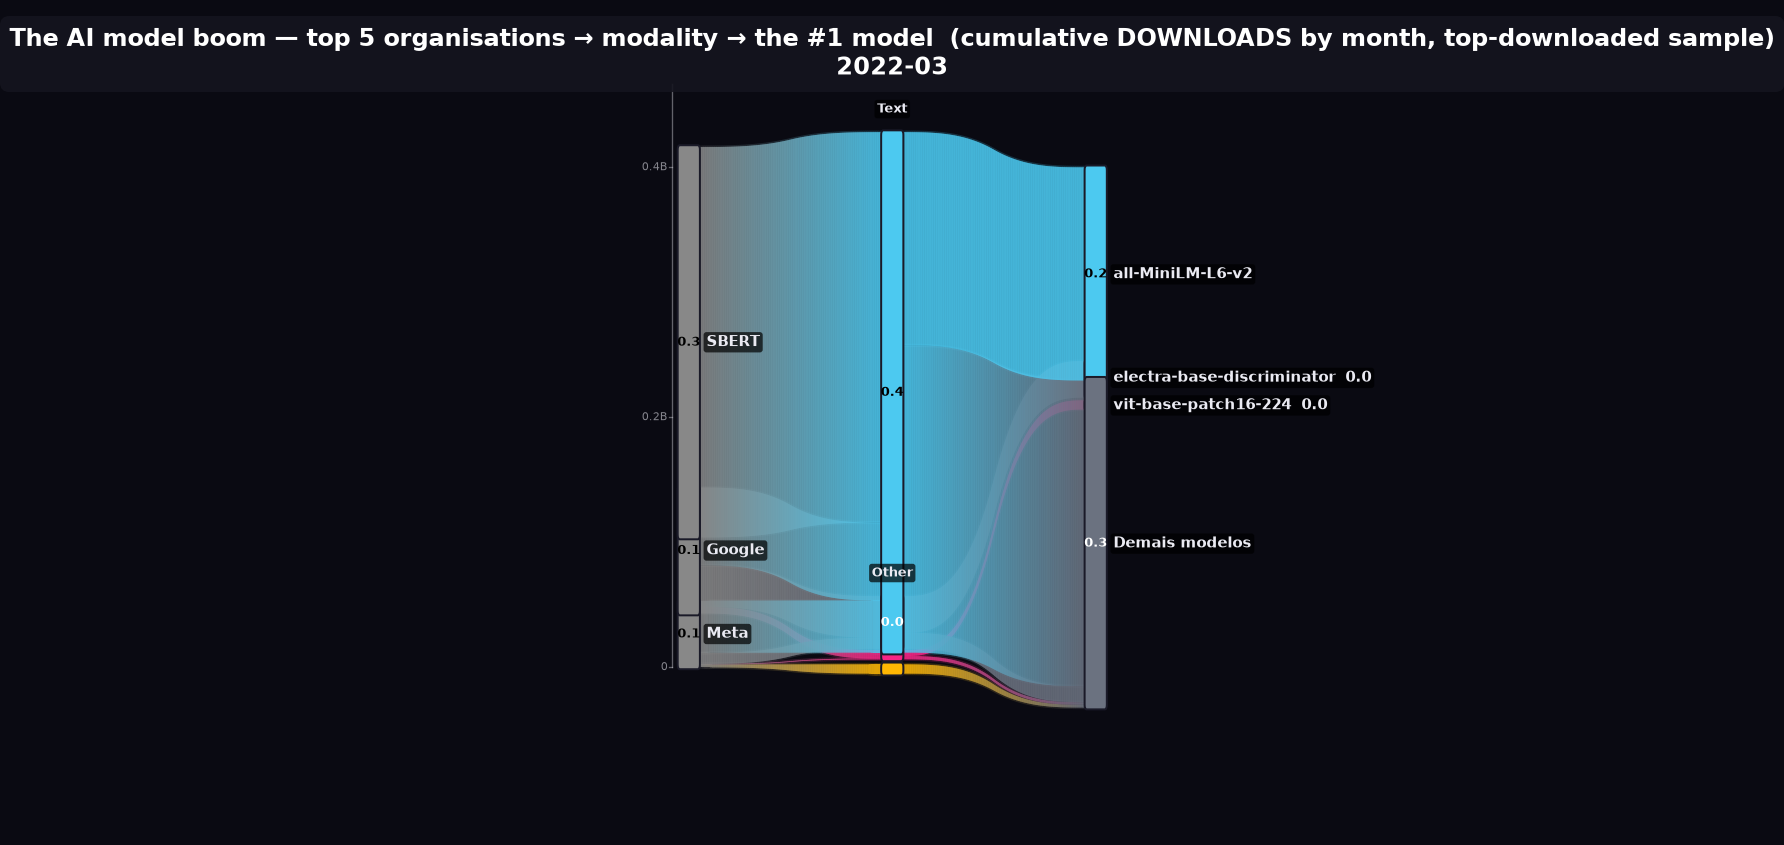

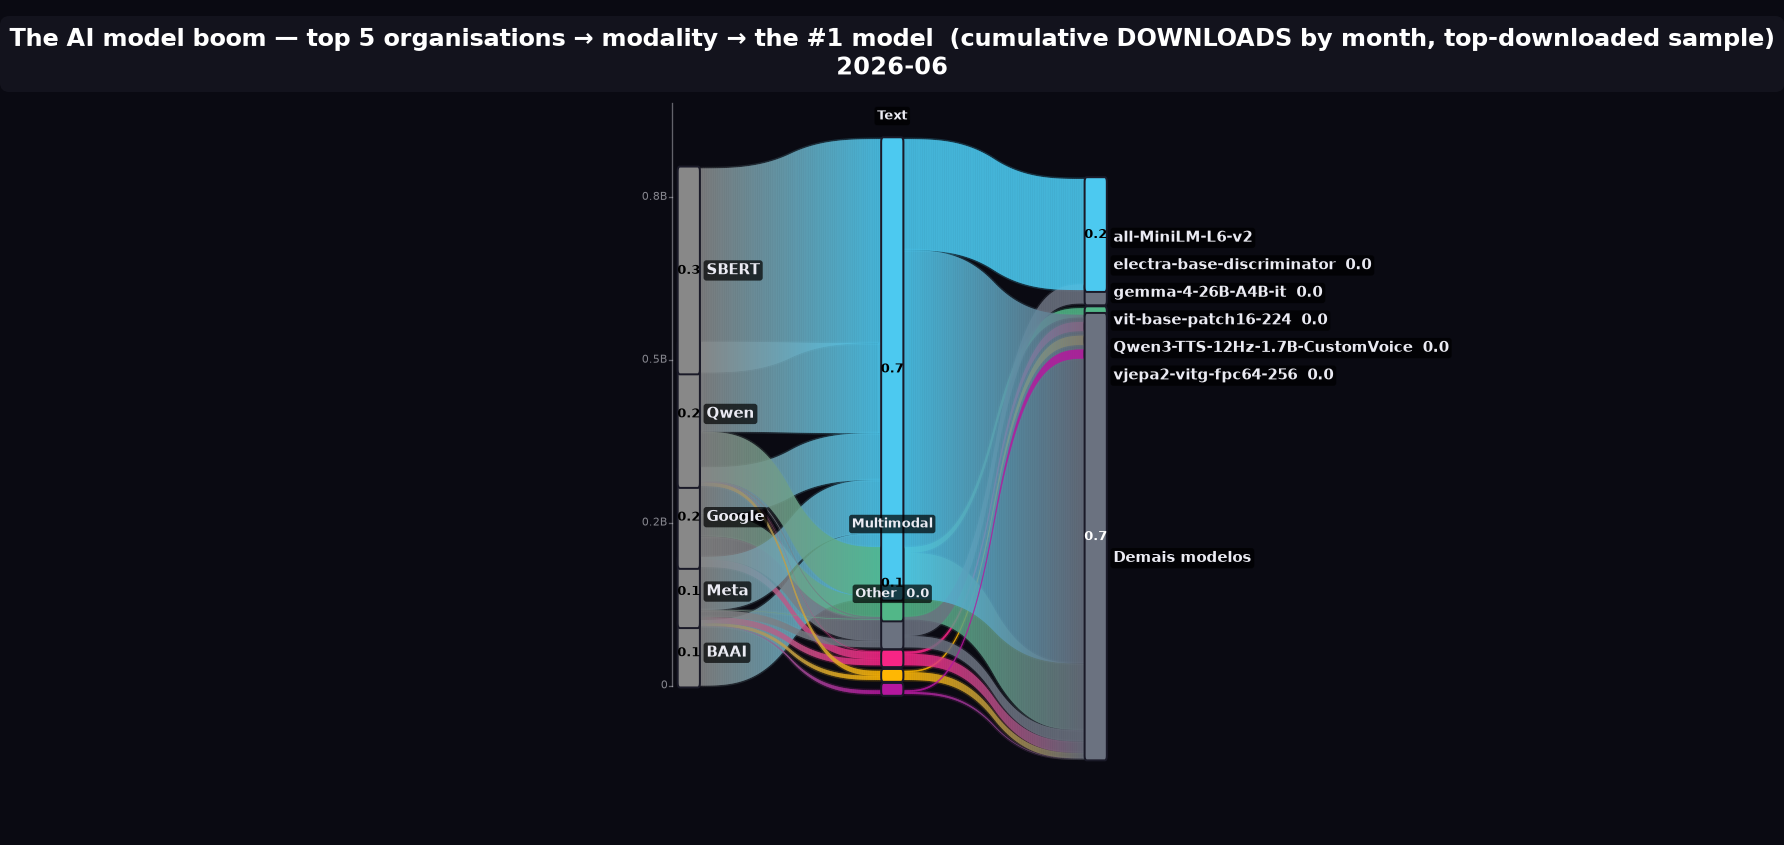

In [12]:
still_design = dict(
    figsize=(16, 9), dpi=95, font_size=11, title_fontsize=18, padding=2.8,
    margin_top=0.16, margin_bottom=0.20,
    ranking_mode=True, stacked_mode=True,            # the race: reorder AND resize
    theme="dark", link_glow=1, link_alpha=0.6, n_segments=100,
    yaxis_node=anchor, yaxis_suffix="B",             # DOWNLOADS axis (billions), scaled to the org-layer total
    yaxis_gap=0.15, layer0_label_side="right",       # axis hugs the orgs; names on the right
    value_prefix="",                                 # downloads, not dollars
)

TITLE = f"The AI model boom — top {len(org_order)} organisations → modality → the #1 model  (cumulative DOWNLOADS by month, top-downloaded sample)"
month_to_index = {f["time_label"]: i for i, f in enumerate(sk.frames)}
still_paths = []
for ym in (months[0], months[-1]):
    p = os.path.join(ASSETS, f"ai_models_{ym}.png")
    sk.save_frame(p, frame_index=month_to_index[ym], title=TITLE, **still_design)
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))



### One short animation — *now* the rank colours come alive 🎬

A tiny clip to prove the motion **and** the dynamic colouring. We keep it short for speed (a few
seconds) but with the **full** reel design: dark theme, glow, the downloads axis, the cumulative‑total
overlay, and — the headline — **`dynamic_color_mode="ranking"` + `"plasma"`**, so the leading org each
month stands out and the flagship models surface in their lane colours. The cell **skips gracefully** if
FFmpeg isn't installed.


In [13]:
sample_mp4 = os.path.join(ASSETS, "ai_models_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=24, duration_seconds=8, quality="medium", n_workers=2,
        title=TITLE,
        font_size=11, title_fontsize=20, padding=2.8,
        margin_top=0.16, margin_bottom=0.23,
        ranking_mode=True, stacked_mode=True,
        dynamic_color_mode="ranking", dynamic_colormap="plasma",     # <-- the star of the demo
        theme="dark", link_glow=1, link_alpha=0.6, n_segments=100,
        yaxis_node=anchor, yaxis_suffix="B", yaxis_gap=0.15, layer0_label_side="right",
        value_prefix="",                                             # downloads, not dollars
        overlay_series=total, overlay_x_labels=xlabels,
        overlay_label="Cumulative downloads of models existing by month  (billions; download-power accrued, not realised monthly traffic)",
        overlay_color="#7CFF6B", overlay_value_suffix="B", overlay_badge="DOWNLOADS",
        overlay_band=(0.18, 0.56),                                   # push the line chart lower
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 3
  - Nodes per layer: [5, 6, 7]
  - FPS: 24, Duration: 8s
  - Quality: medium
  - Total frames: 192
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Ranking
  - Colormap: plasma

Pre-computing 192 frames...


  Pre-computation: 1.75s
  Workers: 2

Rendering on 2 parallel processes...


  Parallel rendering: 370.72s (0.5 fps)

Concatenating 2 chunks...


  Concatenation: 0.78s

Animation saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\ai_models_sample.mp4
Total time: 371.65s (0.5 effective fps)


rendered: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\ai_models_sample.mp4



### Scaling up to a full reel

Everything above is parameterised, so a longer, higher‑resolution reel is just bigger numbers and a longer
`duration_seconds`. From this notebook you'd bump `N_MODELS` (a bigger sample), `N_ORGS` (more orgs on the
left), and the clip length, then re‑run from §3:

```python
N_MODELS = 6000      # a bigger top-by-downloads sample
N_ORGS   = 8         # more organisations in the left column
# ...then re-run §3 onward and lengthen duration_seconds in the animate() call.
```

> 💡 If you save your own renders, stamp every output filename with a **big‑endian, sortable** date‑time
> prefix (`%Y-%m-%d-%Hh%M`, with `:` → `h` because it's illegal in paths) — so your renders always sort
> chronologically. 🗂️



## 10 · Recap & try it yourself

🎉 **You built the whole reel** — from raw Hugging Face Hub JSON to an animated, **three‑layer** gradient
Sankey ranking race of the AI model boom, sized by **downloads**.

**The pipeline, in one breath:** page the top‑downloaded models (cached) → **bucket** `pipeline_tag` into
six modality lanes → rank **orgs by downloads** and **keep only the top‑N** (drop the long tail — no
dominant "Others") → find each lane's **#1 model (flagship)** → build the **cumulative, MONTHLY, balanced
THREE‑layer** long‑form `[month, source, target, value]` (org → modality → flagship + ONE shared *Demais
modelos*) → **monthly** cumulative‑downloads overlay → `from_dataframe` → `save_frame` stills + `animate`
with **`dynamic_color_mode="ranking"`** and a **downloads** axis.

### The balanced layer‑2 → layer‑3 scheme, in one sentence

Per modality, the lane's cumulative downloads split into exactly **two** flows — **`[the #1 model]`** and
**`[the ONE shared "Demais modelos" node]`** — which sum to the lane total, so every modality node has
`in == out` (the diagram **balances**); layer 3 is just **one flagship per lane + 1 shared node**, with the
famous names highlighted and a *single* neutral node absorbing every lane's long tail.

### ⚠️ Caveats, restated honestly

- **Top‑by‑downloads sample, not the full Hub.** We rank/sample by downloads; this is *not* a census of
  every model on the Hub. And with `drop_others=True` we keep **only the top‑N orgs**, so the left column
  is a focused *"top‑N organisations"* view, not the full sampled total — the title says so.
- **`createdAt` ≠ true birth month for landmark models.** Re‑uploads/migrations can date famous old models
  recently; in this sample createdAt barely predates **2022‑03**, so the monthly window starts there.
- **The monthly overlay is download‑power, not realised traffic.** HF `downloads` is a current ~30‑day
  snapshot, so the curve is "cumulative downloads of models *existing* by month m", **not** historically
  realised monthly downloads.
- **Modality is *our* bucketing** of `pipeline_tag`, a judgement call (e.g. `feature-extraction` → Text).
  The rule is explicit in §4 so you can change it.
- **One flagship per lane + one shared remainder.** Every lane's runner‑up models fold into the **single**
  shared *Demais modelos* node; the highlight is deliberately each lane's #1.

### 🧪 Try it yourself

1. **Bigger sample.** Raise `N_MODELS` to 4000–6000 and re‑run from §3 — watch the lanes fill in.
2. **More / fewer orgs.** Tune `N_ORGS` in §6.1 to make the left column taller or shorter — or flip
   `DROP_OTHERS = False` to keep a single neutral **"Others"** bucket for the long tail instead.
3. **Top‑2 per lane.** In §6.2/§6.3, keep the lane's **two** biggest models as separate flagship nodes
   (the shared *Demais modelos* absorbs the rest) and watch a rivalry appear in the right column.
4. **Counts instead of downloads.** Swap `["dl"].sum()` back to `.size()` to weight by *number of models*
   rather than *reach* — and see the bulk uploaders take over (set the axis/overlay units accordingly).
5. **A different colormap.** Swap `dynamic_colormap="plasma"` for `"turbo"` or `"RdYlGn_r"` in the clip.
6. **Coarser cadence.** Set `START_MONTH` earlier, or resample `months` to quarters, for a faster reel.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- Hugging Face Hub API: https://huggingface.co/docs/hub/api  (free, no API key)
- Companion tutorials: `notebooks/02_tutorial_stablecoins.ipynb`,
  `notebooks/01_tutorial_nvidia_income.ipynb`, `notebooks/06_tutorial_refugees.ipynb`

> 💡 Remember: **`dynamic_color_mode="ranking"`**, the neutral pinned **`"Demais modelos"`** hub,
> hiding zero nodes (so flagships appear the month they're born), the **downloads** value axis
> (`value_prefix=""`, `yaxis_suffix="B"`), `yaxis_gap`, `layer0_label_side` and `overlay_band` are
> **local‑only** today — they ship in **v1.3.0**. Until then, import the local module via `sys.path` (as
> we did in §1) and everything just works. 💙

*Built com todo cuidado e carinho. Data: Hugging Face Hub API (free, no API key). Happy hacking!*
